

#### "Smart Mushroom Identifier: Detecting Poisonous Species"


* Mushroom Edibility Prediction Using Machine Learning

* Poisonous or Not? A Mushroom Classification Project

In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [9]:
df = pd.read_csv("mushrooms.csv")

In [10]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

* all are categorical (ie; not continous)

In [16]:
#df.describe()

In [17]:
df['class'].value_counts()  # e --> edible , p --> poisinous 

class
e    4208
p    3916
Name: count, dtype: int64

<Axes: xlabel='class', ylabel='count'>

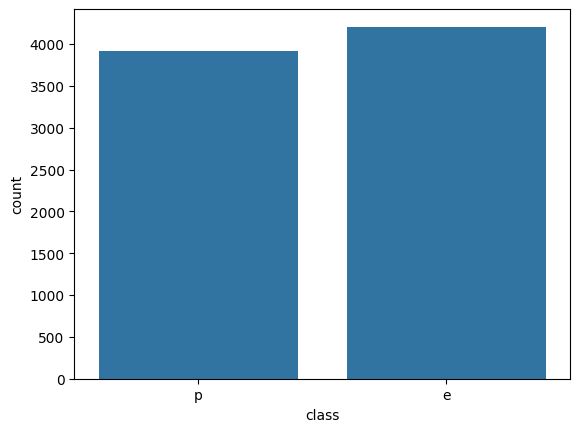

In [19]:
sns.countplot(data = df, x ='class')

* Balanced data set.

In [21]:
df.describe().transpose()

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


In [24]:
df.describe().transpose().reset_index()

,index,count,unique,top,freq
0,class,8124,2,e,4208
1,cap-shape,8124,6,x,3656
2,cap-surface,8124,4,y,3244
3,cap-color,8124,10,n,2284
4,bruises,8124,2,f,4748
5,odor,8124,9,n,3528
6,gill-attachment,8124,2,f,7914
7,gill-spacing,8124,2,c,6812
8,gill-size,8124,2,b,5612
9,gill-color,8124,12,b,1728


In [29]:
des = df.describe().transpose().reset_index().sort_values('unique')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22],
 [Text(0, 0, 'veil-type'),
  Text(1, 0, 'class'),
  Text(2, 0, 'bruises'),
  Text(3, 0, 'gill-attachment'),
  Text(4, 0, 'gill-spacing'),
  Text(5, 0, 'gill-size'),
  Text(6, 0, 'stalk-shape'),
  Text(7, 0, 'ring-number'),
  Text(8, 0, 'cap-surface'),
  Text(9, 0, 'veil-color'),
  Text(10, 0, 'stalk-surface-below-ring'),
  Text(11, 0, 'stalk-surface-above-ring'),
  Text(12, 0, 'ring-type'),
  Text(13, 0, 'stalk-root'),
  Text(14, 0, 'cap-shape'),
  Text(15, 0, 'population'),
  Text(16, 0, 'habitat'),
  Text(17, 0, 'stalk-color-above-ring'),
  Text(18, 0, 'stalk-color-below-ring'),
  Text(19, 0, 'odor'),
  Text(20, 0, 'spore-print-color'),
  Text(21, 0, 'cap-color'),
  Text(22, 0, 'gill-color')])

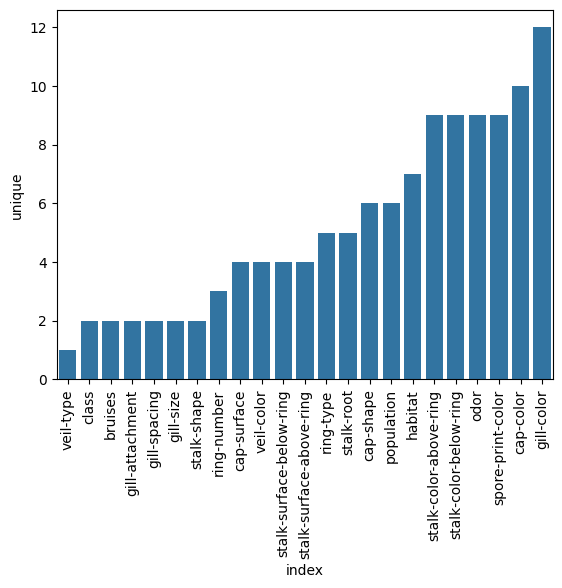

In [31]:
sns.barplot(data = des , x = 'index', y = 'unique')
plt.xticks(rotation = 90)

In [32]:
df['odor'].value_counts()

odor
n    3528
f    2160
s     576
y     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64

### Train-Test split:

In [38]:
X =pd.get_dummies( df.drop('class', axis = 1), drop_first= True) # Feature transformation, similar to one hot encoding and droping the first obivious one. 
X

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,False,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
8120,False,False,False,False,True,False,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False
8121,False,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
8122,False,False,True,False,False,False,False,True,False,False,...,False,False,True,False,False,True,False,False,False,False


In [39]:
y  = df['class']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.15, random_state = 50)

### AdaBoost

In [42]:
from sklearn.ensemble import AdaBoostClassifier

In [44]:
model = AdaBoostClassifier(n_estimators=1) # We are not trying to get the best model, rather we are trying to get that best feature (since we are setting up the guide lines)

### Using AdaBoostClassifier for Feature Importance

Here, we are using **AdaBoostClassifier** not to build a strong predictive model, but as a tool to understand which feature is the most influential for distinguishing between poisonous and edible mushrooms.  

- `n_estimators=1` → means only one weak learner (usually a decision stump).  
- This way, AdaBoost won’t combine multiple learners into a strong model; instead, it will **pick out the single most discriminative feature** for classification.  
- `feature_importances_` → shows how much each feature contributed. The feature with the highest score is likely the most important guideline (e.g., *odor* is usually the strongest feature in the classic mushroom dataset).  


In [45]:
model.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=1)

In [46]:
preds = model.predict(X_test)

### Evaluation

In [47]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [48]:
confusion_matrix(preds, y_test)

array([[495,  28],
       [108, 588]])

In [49]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           e       0.95      0.82      0.88       603
           p       0.84      0.95      0.90       616

    accuracy                           0.89      1219
   macro avg       0.90      0.89      0.89      1219
weighted avg       0.90      0.89      0.89      1219



In [50]:
model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [51]:
# To find whic feature is :
model.feature_importances_.argmax()

22

In [53]:
X.columns[22]

'odor_n'

#### Observation:
* So odor is a very important feature to take in consideration, at the worst case. 